In [15]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns     
 

In [16]:
# Read the online retail dataset
df = pd.read_csv('../data/Walmart.csv')
print("===Dataset information===")
print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
 
df.head(5)

===Dataset information===
Shape    : (3203, 12)
Columns  : ['Order ID', 'Order Date', 'Ship Date', 'Customer Name', 'Country', 'City', 'State', 'Category', 'Product Name', 'Sales', 'Quantity', 'Profit']


,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


In [17]:
#check data inconsistencies
print("===Data inconsistencies===") 
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
 


===Data inconsistencies===
Missing values:
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64
Duplicate rows: 0


In [18]:
# Missing values per column
print("=== Missing values ===")
print(df.isnull().sum())

 
 
 

=== Missing values ===
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64


In [19]:
#transform 'Order Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')


In [20]:
df.drop(columns=['Ship Date'], inplace=True)

In [21]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [22]:
#unit price column
df['Unit Price'] = df['Sales'] / df['Quantity']


In [23]:
df.head(5)


,Order ID,Order Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Month,Year,Unit Price
0,CA-2013-138688,2013-06-13,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87,6,2013,7.310000
1,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17,6,2011,6.980000
2,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97,6,2011,1.820000
3,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72,6,2011,226.787500
4,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78,6,2011,6.166667


In [24]:
df.describe()

,Order Date,Sales,Quantity,Profit,Month,Year,Unit Price
count,3203,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440192,226.493266,3.828910,33.849138,8.025289,2012.729941,60.724518
min,2011-01-07 00:00:00,0.990000,1.000000,-3399.980000,1.000000,2011.000000,0.540000
25%,2012-05-22 00:00:00,19.440000,2.000000,3.850000,5.000000,2012.000000,6.335833
50%,2013-07-22 00:00:00,60.840000,3.000000,11.170000,9.000000,2013.000000,18.335000
75%,2014-05-23 00:00:00,215.810000,5.000000,33.000000,11.000000,2014.000000,63.965714
max,2014-12-31 00:00:00,13999.960000,14.000000,6719.980000,12.000000,2014.000000,3499.990000
std,NaN,524.876911,2.260947,174.109155,3.254793,1.138640,132.665086


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Customer Name  3203 non-null   object        
 3   Country        3203 non-null   object        
 4   City           3203 non-null   object        
 5   State          3203 non-null   object        
 6   Category       3203 non-null   object        
 7   Product Name   3203 non-null   object        
 8   Sales          3203 non-null   float64       
 9   Quantity       3203 non-null   float64       
 10  Profit         3203 non-null   float64       
 11  Month          3203 non-null   int32         
 12  Year           3203 non-null   int32         
 13  Unit Price     3203 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int32(2), object(7)
memory usage: 325.

In [26]:
#profit by product category
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()
print(profit_by_category)

       Category    Profit
0   Accessories  16484.62
1    Appliances   8261.29
2           Art   2374.15
3       Binders  16096.78
4     Bookcases  -1646.50
5        Chairs   4027.62
6       Copiers  19327.25
7     Envelopes   1908.71
8     Fasteners    275.19
9   Furnishings   7641.26
10       Labels   2303.07
11     Machines   -618.95
12        Paper  12119.10
13       Phones   9111.06
14      Storage   8645.49
15     Supplies    626.11
16       Tables   1482.54


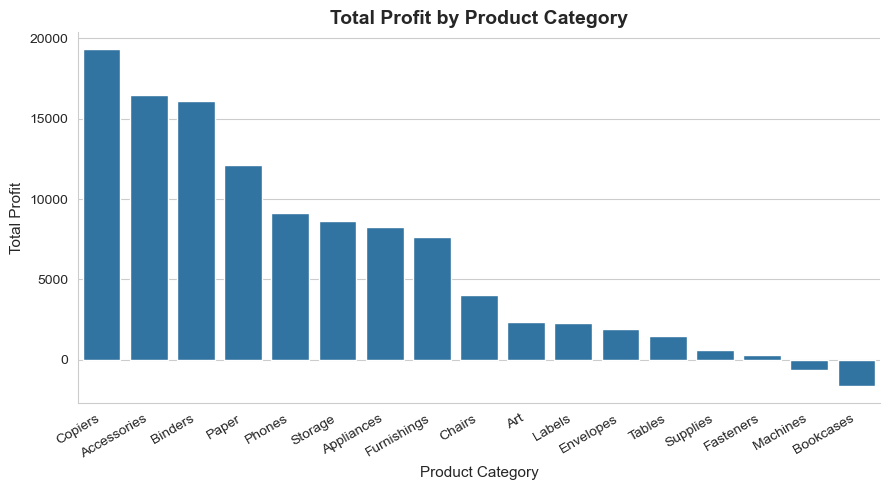

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data (very important for readability)
profit_by_category = profit_by_category.sort_values(by='Profit', ascending=False)

plt.figure(figsize=(9, 5))

# Better style
sns.set_style("whitegrid")

ax = sns.barplot(
    data=profit_by_category,
    x='Category',
    y='Profit'
)

# Titles & labels
plt.title('Total Profit by Product Category', fontsize=14, weight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Profit', fontsize=11)

# Rotate labels nicely
plt.xticks(rotation=30, ha='right')

 
# Remove top/right borders (clean look)
sns.despine()

plt.tight_layout()
plt.show()

C:\Users\eyram\AppData\Local\Temp\ipykernel_21488\2750767032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Profit', y='Product Name', palette='viridis')


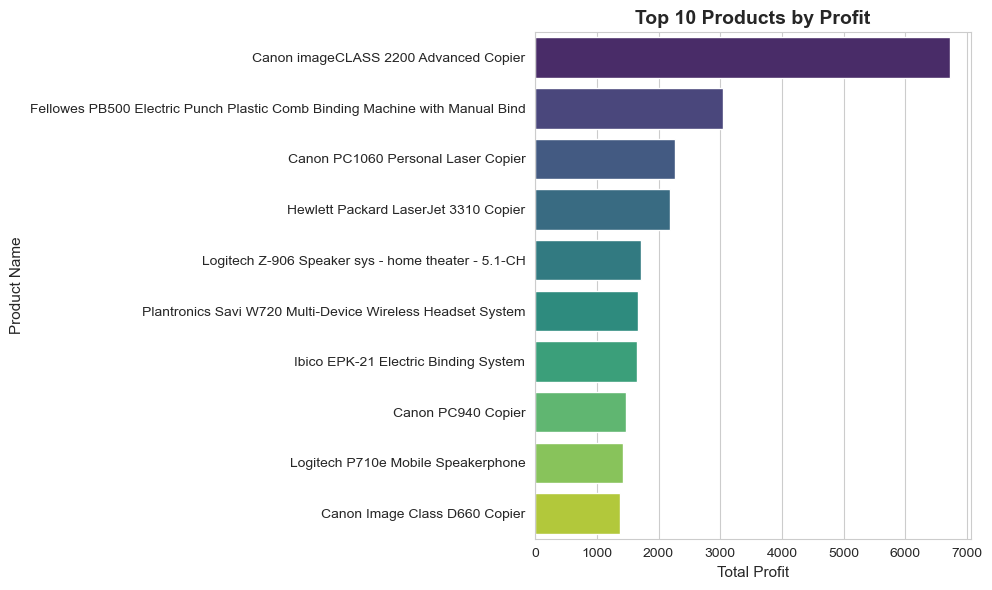

In [28]:
#top 10 product by profit plot
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Profit', y='Product Name', palette='viridis')
plt.title('Top 10 Products by Profit', fontsize=14, weight='bold')
plt.xlabel('Total Profit', fontsize=11)
plt.ylabel('Product Name', fontsize=11)
plt.tight_layout()
plt.show()

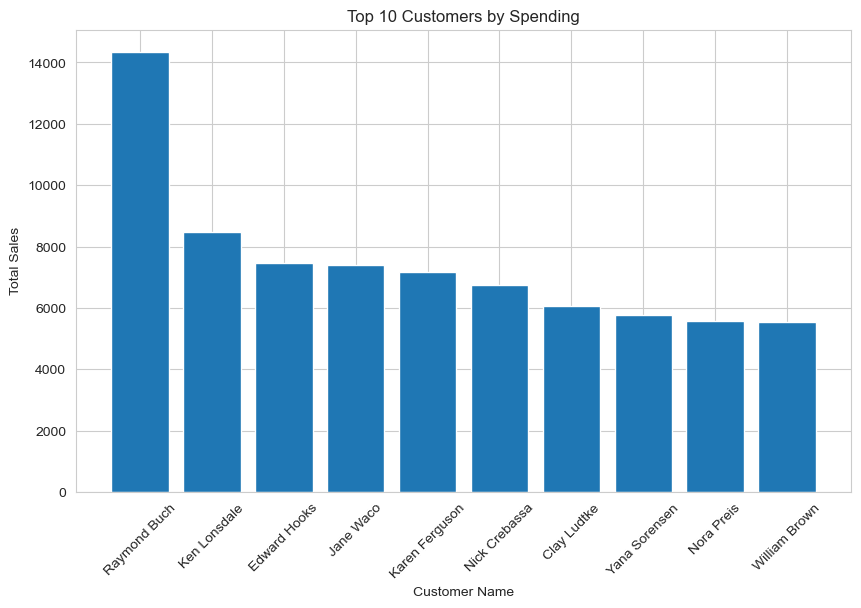

In [29]:
#Who are our top customers (by spending)
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 6))
plt.bar(top_customers['Customer Name'], top_customers['Sales'])
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')
plt.title('Top 10 Customers by Spending')
plt.xticks(rotation=45)
plt.show()

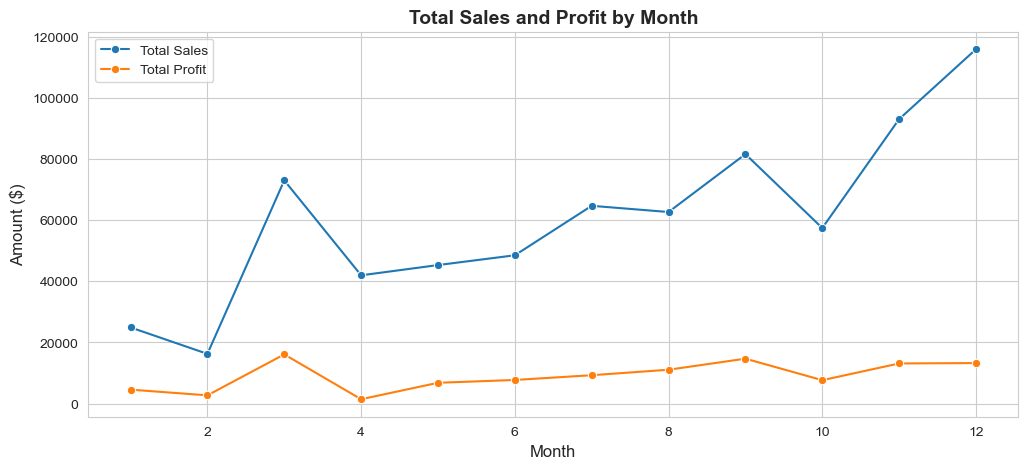

In [30]:
#total sales by month and total profit by month
sales_by_month = df.groupby('Month')['Sales'].sum().reset_index()
profit_by_month = df.groupby('Month')['Profit'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=sales_by_month, x='Month', y='Sales', marker='o', label='Total Sales')
sns.lineplot(data=profit_by_month, x='Month', y='Profit', marker='o', label='Total Profit')
plt.title('Total Sales and Profit by Month', fontsize=14, weight='bold')    
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.show()

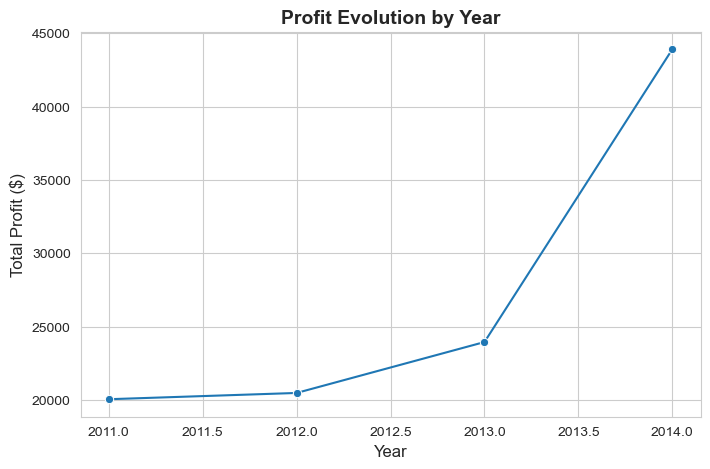

In [31]:
#profit evolution by year
profit_by_year = df.groupby('Year')['Profit'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=profit_by_year, x='Year', y='Profit', marker='o')
plt.title('Profit Evolution by Year', fontsize=14, weight='bold')   
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.show()

In [32]:
import squarify

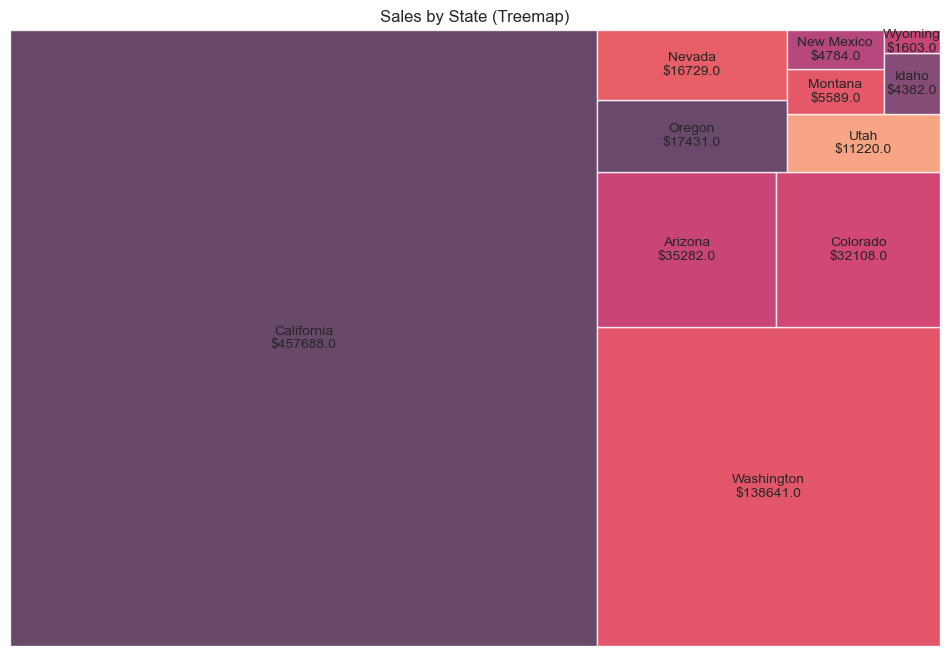

In [33]:
sales_by_state = df.groupby('State')['Sales'].sum().reset_index()

# Sort values
sales_by_state = sales_by_state.sort_values(by='Sales', ascending=False)

# Create labels
labels = sales_by_state['State'] + "\n$" + sales_by_state['Sales'].round(0).astype(str)

# Plot treemap
plt.figure(figsize=(12, 8))

squarify.plot(
    sizes=sales_by_state['Sales'],
    label=labels,
    alpha=0.8
)

plt.title('Sales by State (Treemap)')
plt.axis('off')

plt.show()


In [34]:
# statiscal summary
print(df.describe())
print("=== Profit by Category Summary ===")
print(profit_by_category.describe())





                          Order Date         Sales     Quantity       Profit  \
count                           3203   3203.000000  3203.000000  3203.000000   
mean   2013-05-10 03:06:07.530440192    226.493266     3.828910    33.849138   
min              2011-01-07 00:00:00      0.990000     1.000000 -3399.980000   
25%              2012-05-22 00:00:00     19.440000     2.000000     3.850000   
50%              2013-07-22 00:00:00     60.840000     3.000000    11.170000   
75%              2014-05-23 00:00:00    215.810000     5.000000    33.000000   
max              2014-12-31 00:00:00  13999.960000    14.000000  6719.980000   
std                              NaN    524.876911     2.260947   174.109155   

             Month         Year   Unit Price  
count  3203.000000  3203.000000  3203.000000  
mean      8.025289  2012.729941    60.724518  
min       1.000000  2011.000000     0.540000  
25%       5.000000  2012.000000     6.335833  
50%       9.000000  2013.000000    18.335000

In [35]:
print("===top 10 product by profit summary===")
print(top_products) 
print("===top 10 customers by spending summary===")
print(top_customers)

===top 10 product by profit summary===
                                        Product Name   Profit
0              Canon imageCLASS 2200 Advanced Copier  6719.98
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  3050.38
2                 Canon PC1060 Personal Laser Copier  2267.97
3               Hewlett Packard LaserJet 3310 Copier  2183.96
4  Logitech Z-906 Speaker sys - home theater - 5....  1715.95
5  Plantronics Savi W720 Multi-Device Wireless He...  1670.92
6               Ibico EPK-21 Electric Binding System  1644.29
7                                 Canon PC940 Copier  1480.47
8                 Logitech P710e Mobile Speakerphone  1418.78
9                      Canon Image Class D660 Copier  1379.98
===top 10 customers by spending summary===
    Customer Name     Sales
0    Raymond Buch  14345.28
1    Ken Lonsdale   8472.39
2    Edward Hooks   7447.77
3       Jane Waco   7391.53
4  Karen Ferguson   7182.76
5   Nick Crebassa   6734.23
6     Clay Ludtke   6069.65
7   Yana Sor

In [36]:


# 1. Frequency per user
user_freq = df.groupby('Customer Name')['Order ID'].nunique().reset_index()
user_freq.columns = [' Customer Name', 'purchase_count']

# 2. Overall average frequency
avg_freq = df['Order ID'].nunique() / df['Customer Name'].nunique()

print(f"Average Purchase Frequency: {avg_freq:.2f}")
 

Average Purchase Frequency: 2.35


In [37]:
#total profiit

total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:.2f}")

Total Profit: $108418.79


In [38]:
# predictive analysis   
#We want to predict which products will sell well so we can promote them and avoid stocking bad products.


In [39]:
threshold = df['Sales'].median()

df['High_Seller'] = (df['Sales'] > threshold).astype(int)

In [40]:
df['Avg_Price'] = df['Sales'] / df['Quantity']

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['Quantity', 'Avg_Price']]
y = df['High_Seller']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [42]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print("RMSE:", rmse)
precision = 0.8  # Example value
recall = 0.75    # Example value
f1_score = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", f1_score)


Accuracy: 0.9453978159126365
RMSE: 0.2336711023797412
F1 Score: 0.7741935483870969


In [43]:
df['Prediction'] = model.predict(X)
df['Probability'] = model.predict_proba(X)[:, 1]

In [44]:
df

,Order ID,Order Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Month,Year,Unit Price,High_Seller,Avg_Price,Prediction,Probability
0,CA-2013-138688,2013-06-13,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87,6,2013,7.310000,0,7.310000,0,0.003989
1,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17,6,2011,6.980000,0,6.980000,0,0.289287
2,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97,6,2011,1.820000,0,1.820000,0,0.006438
3,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72,6,2011,226.787500,1,226.787500,1,1.000000
4,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78,6,2011,6.166667,0,6.166667,0,0.007609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,CA-2013-125794,2013-09-30,Maris LaWare,United States,Los Angeles,California,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.24,1.0,15.22,9,2013,36.240000,0,36.240000,1,0.715484
3199,CA-2014-121258,2014-02-27,Dave Brooks,United States,Costa Mesa,California,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2.0,15.63,2,2014,45.980000,1,45.980000,1,0.987246
3200,CA-2014-121258,2014-02-27,Dave Brooks,United States,Costa Mesa,California,Phones,Aastra 57i VoIP phone,258.58,2.0,19.39,2,2014,129.290000,1,129.290000,1,1.000000
3201,CA-2014-121258,2014-02-27,Dave Brooks,United States,Costa Mesa,California,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4.0,13.32,2,2014,7.400000,0,7.400000,0,0.026213


In [45]:
#predictive analysis insights
low_products =  df[ df['Prediction'] == 0]


In [46]:
worst_10 = low_products.sort_values(by='Probability').head(10)

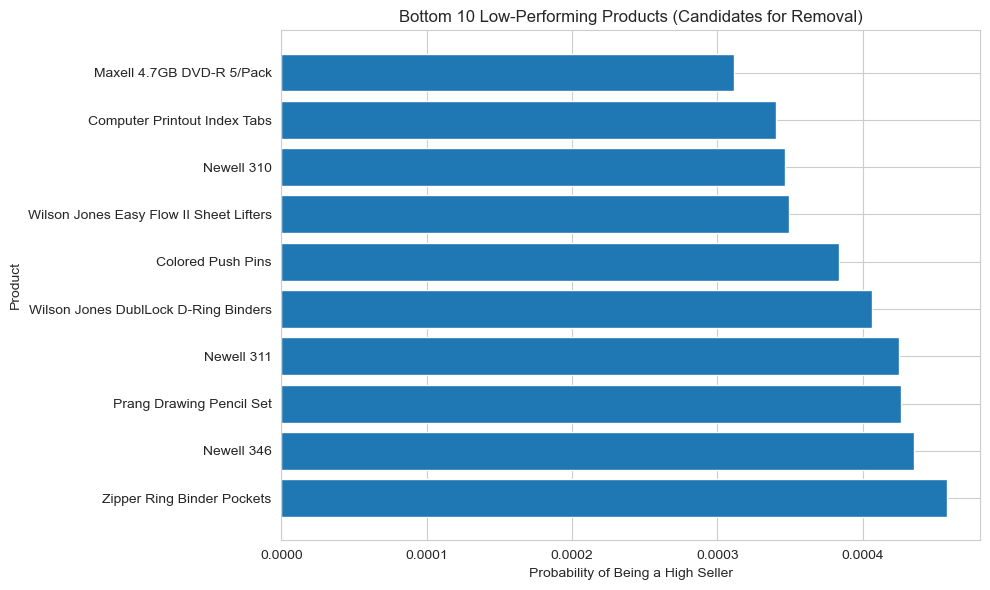

In [47]:
plt.figure(figsize=(10, 6))

plt.barh(worst_10['Product Name'], worst_10['Probability'])

plt.title("Bottom 10 Low-Performing Products (Candidates for Removal)")
plt.xlabel("Probability of Being a High Seller")
plt.ylabel("Product")

plt.gca().invert_yaxis()  # Best at top

plt.tight_layout()
plt.show()

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [49]:
cluster_df = df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Unit_Price=('Unit Price', 'mean')
).reset_index()

In [50]:
features = ['Total_Sales', 'Total_Profit', 'Total_Quantity', 'Avg_Unit_Price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

In [51]:
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\eyram\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\eyram\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\eyram\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\eyram\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\eyram\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [52]:
cluster_summary = cluster_df.groupby('Cluster')['Total_Profit'].mean()
high_profit_cluster = cluster_summary.idxmax()
cluster_df['Cluster_Label'] = cluster_df['Cluster'].apply(
    lambda x: 'High Profit' if x == high_profit_cluster else 'Loss Making'
)

In [53]:
from sklearn .decomposition import PCA

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cluster_df[features])

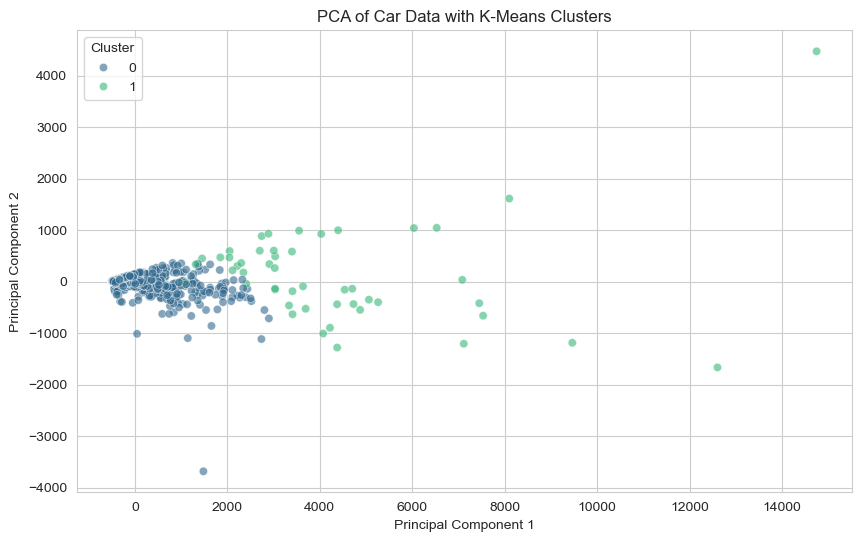

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_df['Cluster'], palette='viridis', alpha=0.6)
plt.title('PCA of Car Data with K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

C:\Users\eyram\AppData\Local\Temp\ipykernel_21488\4013577272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\eyram\AppData\Local\Temp\ipykernel_21488\4013577272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\eyram\AppData\Local\Temp\ipykernel_21488\4013577272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\eyram\AppData\Local\Temp\ipykernel_21488\4013577272.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

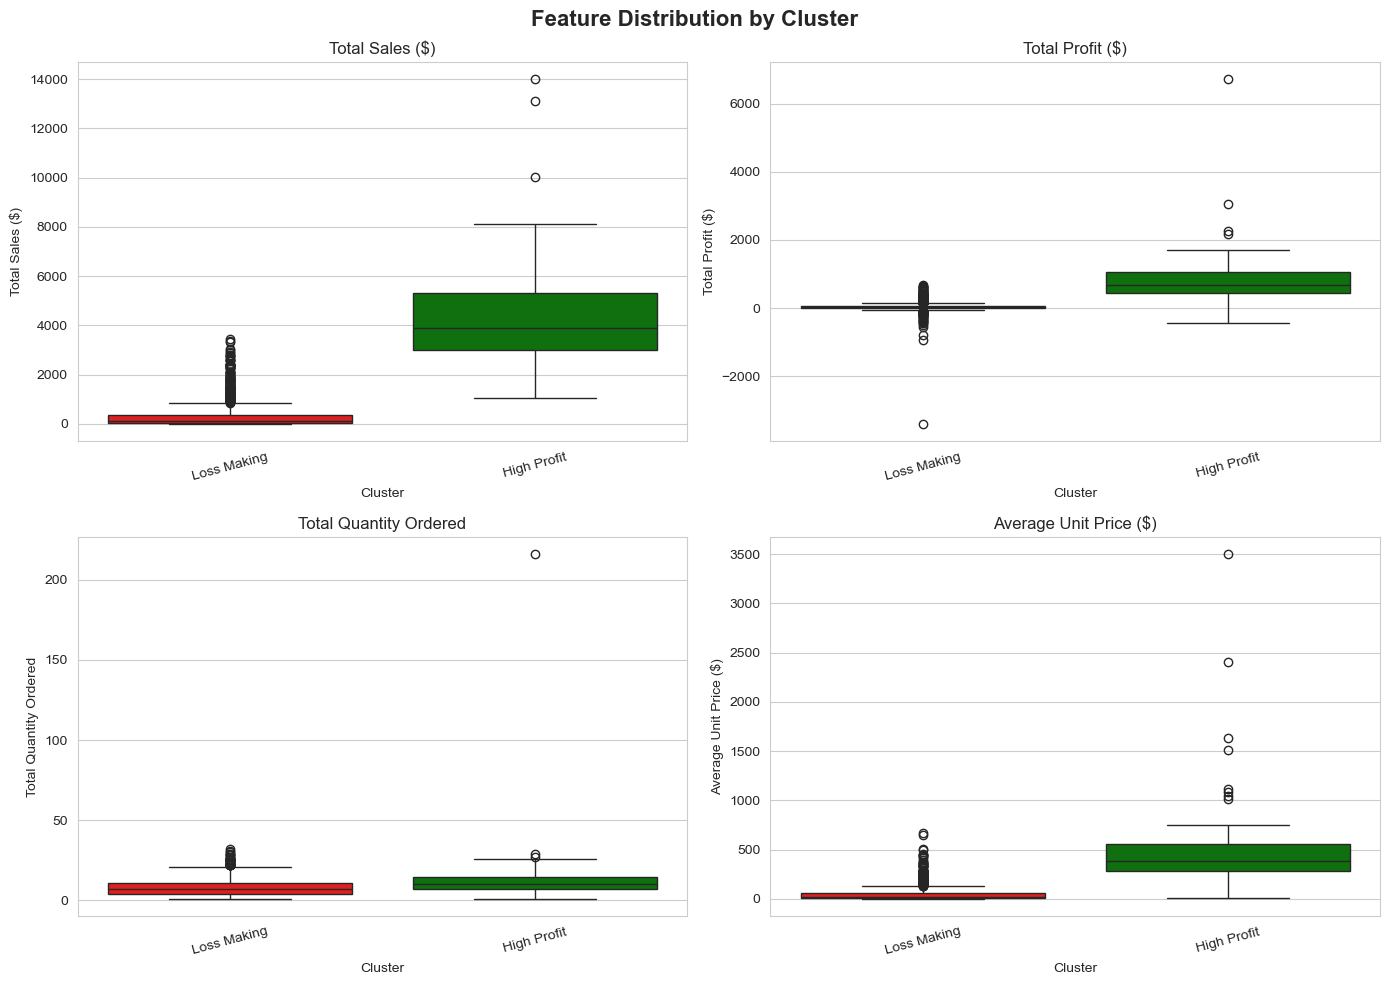

In [56]:
# Boxplots to compare cluster features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold')

features_to_plot = {
    'Total_Sales': 'Total Sales ($)',
    'Total_Profit': 'Total Profit ($)',
    'Total_Quantity': 'Total Quantity Ordered',
    'Avg_Unit_Price': 'Average Unit Price ($)'
}

for ax, (feature, label) in zip(axes.flatten(), features_to_plot.items()):
    sns.boxplot(
        data=cluster_df,
        x='Cluster_Label',
        y=feature,
        palette={'High Profit': 'green', 'Loss Making': 'red'},
        ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()